## Laplace Equation

This notebook is part of the [12 Steps to Navier-Stokes](http://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/) series and covers **Step 9**: the steady-state Laplace equation.

Unlike the time-dependent problems in earlier steps, the Laplace equation has no time derivative — the solution is entirely determined by the boundary conditions:

$$\frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} = 0$$

We solve on the domain $[0, 2] \times [0, 1]$ with the following boundary conditions:

| Boundary | Condition | Type |
|----------|-----------|------|
| $x = 0$ | $p = 0$ | Dirichlet |
| $x = 2$ | $p = y$ | Dirichlet |
| $y = 0$ | $\partial p / \partial y = 0$ | Neumann |
| $y = 1$ | $\partial p / \partial y = 0$ | Neumann |

The two Dirichlet conditions prescribe values directly; the Neumann conditions prescribe zero heat flux through the top and bottom walls.

We use **PETSc** to solve this linear problem in a single step. Devito generates a residual function and a **matrix-free Jacobian** routine that is passed to PETSc's KSP solver — the Jacobian (the discrete Laplacian operator) is applied on-the-fly via the generated stencil kernel, without ever being assembled into a matrix. The Neumann conditions are imposed via a **mirror-stencil** approach: wherever the standard finite-difference stencil would access a ghost point outside the domain, the index is reflected back inside, which is the discrete equivalent of a zero-gradient condition.

## Environment setup

PETSc paths must be set before importing Devito.

In [1]:
import os

os.environ['PETSC_DIR'] = '/home/zl5621/petsc'
os.environ['PETSC_ARCH'] = 'zoe-petsc-section'
os.environ['CC'] = 'mpicc'

## Imports and Devito configuration

In [2]:
import numpy as np
%matplotlib inline

from devito import (Grid, Function, Eq, Operator, switchconfig,
                    configuration, SubDomain)
from devito.petsc import petscsolve, EssentialBC
from devito.petsc.initialize import PetscInitialize
from devito.symbolics import retrieve_functions, INT
from examples.cfd import plot_field

configuration['compiler'] = 'custom'

PetscInitialize()

Operator `kernel_init` ran in 0.06 s


## Boundary subdomains

We define four thin subdomains — one cell deep — covering each edge of the grid. The **left** and **right** subdomains span the full height of the domain (including corners) and will carry **Dirichlet** conditions via `EssentialBC`. The **bottom** and **top** subdomains cover only the interior columns (excluding corners already owned by the left/right subdomains) and will carry **Neumann** conditions via the mirror-stencil approach.

In [3]:
class SubLeft(SubDomain):
    name = 'subleft'

    def define(self, dimensions):
        x, y = dimensions
        return {x: ('left', 1), y: y}   # full height, leftmost x


class SubRight(SubDomain):
    name = 'subright'

    def define(self, dimensions):
        x, y = dimensions
        return {x: ('right', 1), y: y}  # full height, rightmost x


class SubBottom(SubDomain):
    name = 'subbottom'

    def define(self, dimensions):
        x, y = dimensions
        return {x: ('middle', 1, 1), y: ('left', 1)}   # interior x, bottom y


class SubTop(SubDomain):
    name = 'subtop'

    def define(self, dimensions):
        x, y = dimensions
        return {x: ('middle', 1, 1), y: ('right', 1)}  # interior x, top y


sub_left   = SubLeft()
sub_right  = SubRight()
sub_bottom = SubBottom()
sub_top    = SubTop()

subdomains = (sub_left, sub_right, sub_bottom, sub_top)

## Neumann BC helpers

A zero-Neumann condition $\partial p / \partial y = 0$ on a boundary row is equivalent to placing a **mirror image** of the interior field outside the domain: the ghost-point value at $y = -1$ is replaced by the real value at $y = +1$, and similarly at $y = n_y$.

The helper functions below walk the Devito equation's symbolic stencil and substitute any out-of-bounds index with its mirror. The modified equation is then passed to `petscsolve` for the boundary rows, while the unmodified equation is used for all interior rows.

In [4]:
def neumann_bottom(eq, subdomain):
    """Mirror the stencil at the bottom (y=0) boundary to impose dp/dy=0."""
    lhs, rhs = eq.evaluate.args
    yfs = subdomain.dimensions[-1]   # y sub-dimension on this boundary
    y   = yfs.parent
    funcs = retrieve_functions(lhs - rhs)
    mapper = {}
    for f in funcs:
        yind = f.indices[-1]
        if (yind - y).as_coeff_Mul()[0] < 0:   # index is below y=0
            mapper[f] = f.subs({yind: INT(abs(yind))})
    return Eq(lhs.subs(mapper), rhs.subs(mapper), subdomain=subdomain)


def neumann_top(eq, subdomain):
    """Mirror the stencil at the top (y=ny-1) boundary to impose dp/dy=0."""
    lhs, rhs = eq.evaluate.args
    yfs = subdomain.dimensions[-1]
    y   = yfs.parent
    funcs = retrieve_functions(lhs - rhs)
    mapper = {}
    for f in funcs:
        yind = f.indices[-1]
        if (yind - y).as_coeff_Mul()[0] > 0:   # index is above y=ny-1
            tmp = y - INT(abs(y.symbolic_max - yind))
            mapper[f] = f.subs({yind: tmp})
    return Eq(lhs.subs(mapper), rhs.subs(mapper), subdomain=subdomain)

## Problem setup

We use a $31 \times 31$ grid on the domain $[0, 2] \times [0, 1]$, matching the original tutorial. The boundary-value function `bc` is initialised with $p = 0$ on the left edge and $p = y$ (a linear ramp from $0$ to $1$) on the right edge; the top and bottom edges will be handled by the Neumann helpers and need no prescribed values.

In [5]:
nx = 31
ny = 31
xmax = 2.
ymax = 1.

grid = Grid(
    shape=(nx, ny), extent=(xmax, ymax),
    subdomains=subdomains, dtype=np.float64
)

# Pressure field (unknown)
p = Function(name='p', grid=grid, space_order=2, dtype=np.float64)

# Boundary value function: p=0 at x=0, p=y at x=2
bc = Function(name='bc', grid=grid, space_order=2, dtype=np.float64)
bc.data[:] = 0.
bc.data[-1, :] = np.linspace(0, 1, ny)  # p = y  at x = 2

## Solve with PETSc

We express the Laplace equation $\nabla^2 p = 0$ symbolically, then build the full equation list:

- **Interior**: standard Laplacian stencil
- **Bottom / Top**: Laplacian stencil with mirrored ghost points (Neumann)
- **Left / Right**: Dirichlet values via `EssentialBC`

All of these are passed to `petscsolve`. Devito generates a residual function and a matrix-free Jacobian routine from the symbolic stencil; PETSc's KSP solver applies the Jacobian on-the-fly — it is never assembled into a matrix.

In [6]:
#NBVAL_IGNORE_OUTPUT
eqn = Eq(p.laplace, 0, subdomain=grid.interior)

# Neumann BCs: mirror-stencil equations on the bottom and top rows
bcs  = [neumann_bottom(eqn, sub_bottom)]
bcs += [neumann_top(eqn, sub_top)]

# Dirichlet BCs: prescribed values on the left and right edges
bcs += [EssentialBC(p, bc, subdomain=sub_left)]
bcs += [EssentialBC(p, bc, subdomain=sub_right)]

petsc = petscsolve([eqn] + bcs, target=p, solver_parameters={'ksp_rtol': 1e-8})

with switchconfig(language='petsc'):
    op = Operator(petsc)
    op.apply()

Operator `Kernel` ran in 0.08 s


## Visualise the solution

The solution shows the expected steady-state: $p = 0$ along the cold left wall ($x = 0$), rising smoothly to the linear profile $p = y$ along the right wall ($x = 2$), with zero slope at the top and bottom.

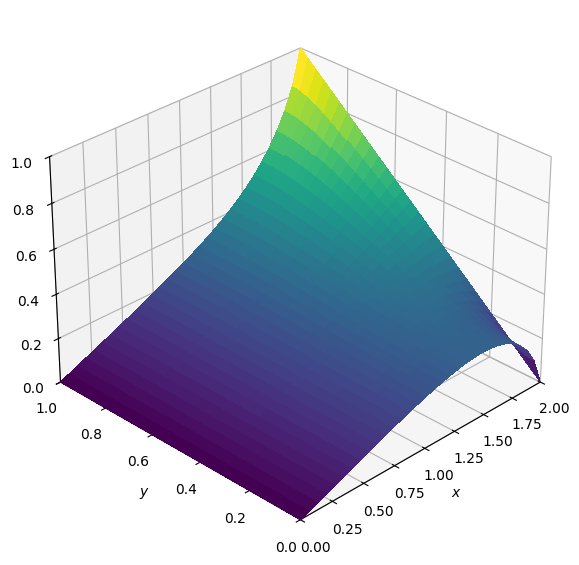

In [7]:
#NBVAL_IGNORE_OUTPUT
plot_field(p.data, xmax=xmax, ymax=ymax, view=(30, 225))